# Financial Inclusion — XGBoost Model

---

## Was ist XGBoost?

XGBoost steht für *Extreme Gradient Boosting*. Das Grundprinzip ist **Boosting** — statt einen einzigen starken Baum zu bauen, werden viele kleine, schwache Bäume hintereinander trainiert. Jeder neue Baum konzentriert sich dabei auf die Fehler des vorherigen und versucht diese zu korrigieren. Am Ende stimmen alle Bäume gemeinsam ab — das Ergebnis ist deutlich robuster als ein einzelner Entscheidungsbaum.

**Warum XGBoost?**
- Einer der stärksten Algorithmen für tabellarische Daten
- Sehr schnell durch Parallelisierung
- Eingebaute Regularisierung gegen Overfitting
- Kann mit Klassenimbalance umgehen (`scale_pos_weight`)
- Gewinnt regelmäßig Kaggle/Zindi-Wettbewerbe

**Unser Ziel:** Vorhersage ob eine Person ein Bankkonto besitzt (`bank_account = 1`) oder nicht (`bank_account = 0`) — mit Fokus auf **Financial Inclusion**: wir wollen möglichst niemanden ausschließen der eigentlich berechtigt wäre.

---

**Datengrundlage:** `features_encoded_train.csv` — bereits enkodierte Features aus `Train_Encoding.ipynb`

---
### Step 0 — Imports

Wir laden:
- **pandas / numpy** — Datenverarbeitung
- **xgboost** — unser Modell
- **sklearn** — Train/Val-Split, Metriken, Confusion Matrix
- **matplotlib / seaborn** — Visualisierungen

In [98]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

print('Alle Imports erfolgreich.')

Alle Imports erfolgreich.


---
### Step 1 — Daten laden & aufteilen (X / y)

Wir laden `features_encoded_train.csv` und trennen:
- **X** — alle Feature-Spalten (Eingabe für das Modell)
- **y** — die Zielspalte `target_bank_account` (was das Modell vorhersagen soll)

Die Zielverteilung zeigt uns ob die Klassen **unbalanced** sind — das beeinflusst wie wir XGBoost konfigurieren.

In [99]:
df = pd.read_csv('data/features_encoded_train.csv')

X = df.drop(columns=['target_bank_account'])
y = df['target_bank_account']

print(f'Zeilen: {len(df):,}')
print(f'Features (X): {X.shape[1]} Spalten')
print(f'\nZielverteilung (y):')
print(f'  Kein Konto (0): {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)')
print(f'  Konto     (1): {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)')

Zeilen: 23,524
Features (X): 17 Spalten

Zielverteilung (y):
  Kein Konto (0): 20,212  (85.9%)
  Konto     (1): 3,312  (14.1%)


---
### Step 2 — Train/Validation-Split

Wir teilen die Daten in **80% Training** und **20% Validation** auf.

- Das Modell lernt nur auf den Trainingsdaten
- Die Validation-Daten sind "unsichtbar" während des Trainings — damit messen wir wie gut das Modell auf neuen Daten funktioniert
- `stratify=y` stellt sicher dass die Klassenverteilung (85/15) in beiden Splits erhalten bleibt

In [100]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Trainingsdaten  : {len(X_train):,} Zeilen ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validierungsdaten: {len(X_val):,} Zeilen ({len(X_val)/len(X)*100:.0f}%)')
print(f'\nKlassenverteilung Training:')
print(f'  Kein Konto (0): {(y_train == 0).sum():,}  ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Konto     (1): {(y_train == 1).sum():,}  ({(y_train == 1).mean()*100:.1f}%)')

Trainingsdaten  : 18,819 Zeilen (80%)
Validierungsdaten: 4,705 Zeilen (20%)

Klassenverteilung Training:
  Kein Konto (0): 16,169  (85.9%)
  Konto     (1): 2,650  (14.1%)


---
### Step 3 — XGBoost Baseline trainieren

#### Wie lernt XGBoost?

XGBoost baut Bäume sequenziell. Der erste Baum macht eine Vorhersage — danach schaut XGBoost welche Personen falsch klassifiziert wurden und gewichtet diese stärker. Der zweite Baum versucht genau diese schwierigen Fälle besser zu treffen. Dieser Prozess wiederholt sich `n_estimators`-mal. Am Ende addiert XGBoost die Beiträge aller Bäume — gewichtet durch die `learning_rate`.

**Analogie:** Stelle dir vor du lernst Gitarre. Nach jeder Übungsstunde konzentrierst du dich auf die Stellen die du noch nicht kannst — nicht auf die die schon gut sitzen. Genau so lernt XGBoost.

#### Parameter die wir setzen:

| Parameter | Wert | Erklärung |
|---|---|---|
| `n_estimators` | 300 | Anzahl der Bäume — mehr Bäume = mehr Lernkapazität, aber ab einem Punkt kein Gewinn mehr |
| `max_depth` | 4 | Wie tief jeder Baum wachsen darf — tiefere Bäume lernen komplexere Muster, riskieren aber Overfitting |
| `learning_rate` | 0.05 | Wie stark jeder neue Baum das Gesamtergebnis beeinflusst — kleiner = stabiler aber langsamer |
| `scale_pos_weight` | natürlich × 1.5 | Financial Inclusion: Fehler bei "hat Konto" werden stärker bestraft als Fehler bei "hat kein Konto" |
| `eval_metric` | `auc` | XGBoost überwacht intern AUC während des Trainings |

> Dieses Modell ist unser **Ausgangspunkt** — ein vernünftiges erstes Modell ohne viel Aufwand. In den folgenden Steps verfeinern wir es systematisch.

In [101]:
# Natürliches Klassengewicht × 1.5 für Financial Inclusion
# → Modell bestraft False Negatives (Berechtigte die ausgeschlossen werden) stärker
natural_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight = natural_weight * 1.5
print(f'Natürliches Gewicht : {natural_weight:.2f}')
print(f'Financial Inclusion : {scale_pos_weight:.2f}  (× 1.5)')

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print('Training abgeschlossen.')

Natürliches Gewicht : 6.10
Financial Inclusion : 9.15  (× 1.5)
Training abgeschlossen.


---
### Step 4 — Evaluation

Wir messen die Modellqualität mit zwei Methoden:

1. **ROC-AUC Score** — Hauptmetrik des Wettbewerbs. Misst wie gut das Modell zwischen Konto/kein Konto unterscheidet. 1.0 = perfekt, 0.5 = Zufall.
2. **Confusion Matrix** — zeigt wie viele Fälle korrekt/falsch klassifiziert wurden (True Positive, False Positive, etc.)

ROC-AUC (Validation): 0.8738

                precision    recall  f1-score   support

Kein Konto (0)       0.97      0.71      0.82      4043
     Konto (1)       0.33      0.86      0.47       662

      accuracy                           0.73      4705
     macro avg       0.65      0.79      0.65      4705
  weighted avg       0.88      0.73      0.77      4705



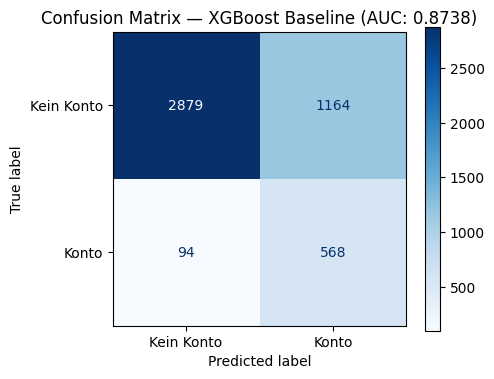

In [102]:
# Wahrscheinlichkeiten und binäre Predictions
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred  = model.predict(X_val)

# ROC-AUC
auc = roc_auc_score(y_val, y_val_proba)
print(f'ROC-AUC (Validation): {auc:.4f}')
print()

# Classification Report
print(classification_report(y_val, y_val_pred, target_names=['Kein Konto (0)', 'Konto (1)']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=['Kein Konto', 'Konto'],
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix — XGBoost Baseline (AUC: {auc:.4f})')
plt.tight_layout()
plt.show()

---
### Step 5 — Feature Importance

XGBoost kann uns zeigen welche Features am meisten zur Vorhersage beigetragen haben.

Wir nutzen `weight` als Importance-Typ — er zählt wie oft ein Feature über alle Bäume hinweg für einen Split verwendet wurde. Je höher, desto relevanter.

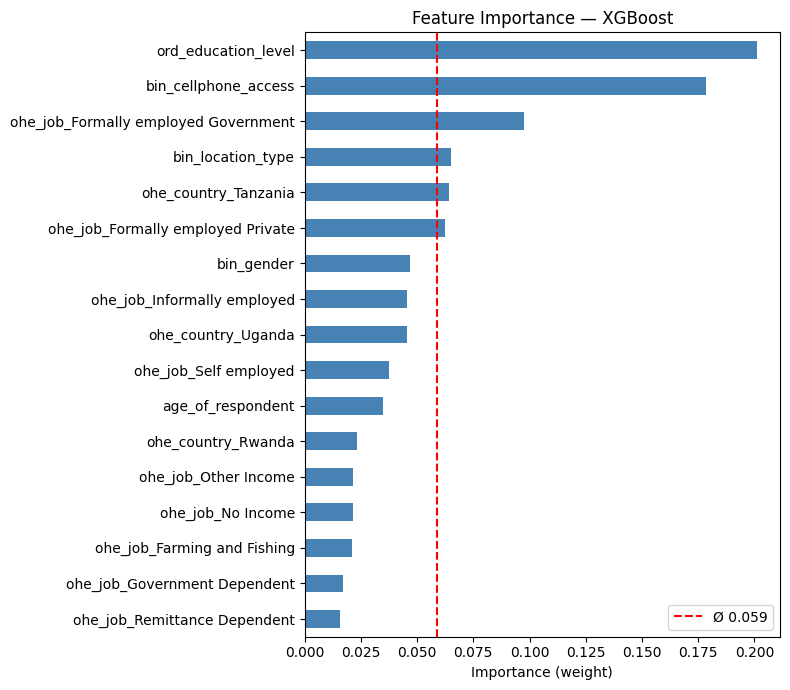


Top 5 wichtigste Features:
  ord_education_level                           0.2013
  bin_cellphone_access                          0.1785
  ohe_job_Formally employed Government          0.0978
  bin_location_type                             0.0651
  ohe_country_Tanzania                          0.0640


In [103]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — XGBoost')
ax.set_xlabel('Importance (weight)')
ax.axvline(importance.mean(), color='red', linestyle='--', label=f'Ø {importance.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 wichtigste Features:')
for feat, val in importance.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<45} {val:.4f}')

---
### Tuning-Strategie — Übersicht

Bevor wir mit dem eigentlichen Tuning anfangen: hier die Gesamtstrategie damit klar ist warum wir die Schritte in dieser Reihenfolge machen.

**Das Problem:** Der Baseline-Modell aus Step 3 hat vernünftige Parameter — aber "vernünftig" ist nicht "optimal". Es gibt Dutzende von Stellschrauben und wir wissen nicht welche Kombination am besten funktioniert. Das Tuning ist ein systematisches Ausprobieren.

**Die Reihenfolge:**

| Step | Was wird getuned | Warum in dieser Reihenfolge |
|---|---|---|
| **6** | `n_estimators`, `max_depth`, `learning_rate` | Die drei wichtigsten Parameter zuerst — sie haben den größten Einfluss |
| **6b** | + `subsample`, `colsample_bytree`, `min_child_weight`, `gamma` | Sampling- und Regularisierungsparameter auf Baum-Ebene |
| **6c** | Entscheidungs-Threshold | Unabhängig vom Modell — wie aggressiv klassifizieren wir? |
| **6d** | `scale_pos_weight` | Financial Inclusion spezifisch — wie stark bestrafen wir False Negatives? |
| **6e** | `reg_alpha`, `reg_lambda` | Gewichts-Regularisierung — letzter Schliff gegen Overfitting |
| **6f** | Alle Parameter gemeinsam | Optuna findet Wechselwirkungen die schrittweises Tuning übersieht |

**Wichtig:** Jeder Schritt baut auf dem besten Ergebnis des vorherigen auf. Am Ende vergleichen wir alle Modelle direkt gegeneinander.

---
### Step 6 — Hyperparameter Tuning: Erste Runde (GridSearchCV)

`GridSearchCV` testet **alle möglichen Kombinationen** aus dem definierten Parameter-Grid systematisch durch. Bei 3 Parametern mit je 2–3 Werten sind das 18 Kombinationen — jede wird mit 3-facher Cross-Validation bewertet. So bekommen wir für jede Kombination einen ehrlichen Durchschnittswert statt einem zufälligen Einzel-Ergebnis.

**Scoring = `recall`:** Wir optimieren nicht auf AUC sondern direkt auf Recall — weil unser Ziel Financial Inclusion ist und wir False Negatives minimieren wollen.

In [104]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [200, 400],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}

base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='recall',       # Financial Inclusion: Recall maximieren
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'\nBeste Parameter : {grid_search.best_params_}')
print(f'Bester CV-Recall: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Beste Parameter : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Bester CV-Recall: 0.9053


In [105]:
# Bestes Modell auf Validation evaluieren
best_model = grid_search.best_estimator_

y_val_proba_tuned = best_model.predict_proba(X_val)[:, 1]
y_val_pred_tuned  = best_model.predict(X_val)

auc_tuned = roc_auc_score(y_val, y_val_proba_tuned)

print(f'ROC-AUC Baseline : {auc:.4f}')
print(f'ROC-AUC Tuned    : {auc_tuned:.4f}  ({auc_tuned - auc:+.4f})')

ROC-AUC Baseline : 0.8738
ROC-AUC Tuned    : 0.8453  (-0.0284)


#### Ergebnis Step 6 — Vergleich Baseline vs. GridSearch

Wir vergleichen den ROC-AUC des Baseline-Modells (Step 3) mit dem besten GridSearch-Modell auf dem Validation-Set. Da wir auf `recall` optimiert haben, kann der AUC leicht sinken — das ist ein bewusster Trade-off für Financial Inclusion.

---
### Step 6b — Erweitertes Tuning mit RandomizedSearchCV

Wir erweitern den Parameterraum deutlich und nutzen `RandomizedSearchCV` — es zieht zufällig Kombinationen aus dem Grid statt alle zu testen. So können wir viel mehr Parameter abdecken bei ähnlicher Laufzeit.

Neue Parameter gegenüber Step 6:

| Parameter | Wirkung |
|---|---|
| `subsample` | Anteil der Trainingszeilen pro Baum — reduziert Overfitting |
| `colsample_bytree` | Anteil der Features pro Baum — wie Random Forest Idee |
| `min_child_weight` | Mindestgewicht in einem Blatt — verhindert zu spezifische Splits |
| `gamma` | Mindest-Informationsgewinn für einen Split — zusätzliche Regularisierung |

> 50 zufällige Kombinationen × 3 Folds = 150 Fits — ca. 2–3 Minuten.

In [106]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [200, 300, 400, 500, 600],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.2, 0.3],
}

rand_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=RANDOM_STATE,
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring='recall',       # Financial Inclusion: Recall maximieren
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)

rand_search.fit(X_train, y_train)

print(f'\nBeste Parameter:')
for k, v in rand_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nBester CV-Recall (RandomizedSearch): {rand_search.best_score_:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Beste Parameter:
  subsample             : 0.9
  n_estimators          : 300
  min_child_weight      : 5
  max_depth             : 4
  learning_rate         : 0.01
  gamma                 : 0.3
  colsample_bytree      : 1.0

Bester CV-Recall (RandomizedSearch): 0.8577


In [107]:
# Vergleich aller drei Modelle
best_model_v2 = rand_search.best_estimator_

y_val_proba_v2 = best_model_v2.predict_proba(X_val)[:, 1]
auc_v2 = roc_auc_score(y_val, y_val_proba_v2)

print(f'ROC-AUC Baseline (Step 3)   : {auc:.4f}')
print(f'ROC-AUC GridSearch (Step 6) : {auc_tuned:.4f}  ({auc_tuned - auc:+.4f})')
print(f'ROC-AUC RandomizedSearch    : {auc_v2:.4f}  ({auc_v2 - auc:+.4f})')
print()
print(f'Bestes Modell: {"RandomizedSearch" if auc_v2 >= auc_tuned else "GridSearch"}')

ROC-AUC Baseline (Step 3)   : 0.8738
ROC-AUC GridSearch (Step 6) : 0.8453  (-0.0284)
ROC-AUC RandomizedSearch    : 0.8644  (-0.0094)

Bestes Modell: RandomizedSearch


#### Ergebnis Step 6b — Vergleich aller drei Modelle

Jetzt haben wir drei Modelle: Baseline, GridSearch und RandomizedSearch. Das beste davon nehmen wir als Ausgangspunkt für Step 6c (Threshold-Tuning). Da RandomizedSearch einen größeren Parameterraum abdeckt, wird es meistens besser abschneiden als GridSearch.

---
### Step 6c — Threshold Tuning für Financial Inclusion

**Ziel:** Niemanden ausschließen der eigentlich ein Konto bekommen sollte → **Recall maximieren**, False Negatives minimieren.

Standardmäßig klassifiziert das Modell ab Wahrscheinlichkeit `0.5` als "Konto". Wir senken diesen Schwellwert — dadurch wird das Modell großzügiger und schließt weniger Berechtigte aus.

Wir plotten den Trade-off zwischen **Recall** und **Precision** über alle möglichen Schwellwerte und wählen den Punkt wo Recall hoch ist ohne Precision komplett zu opfern.

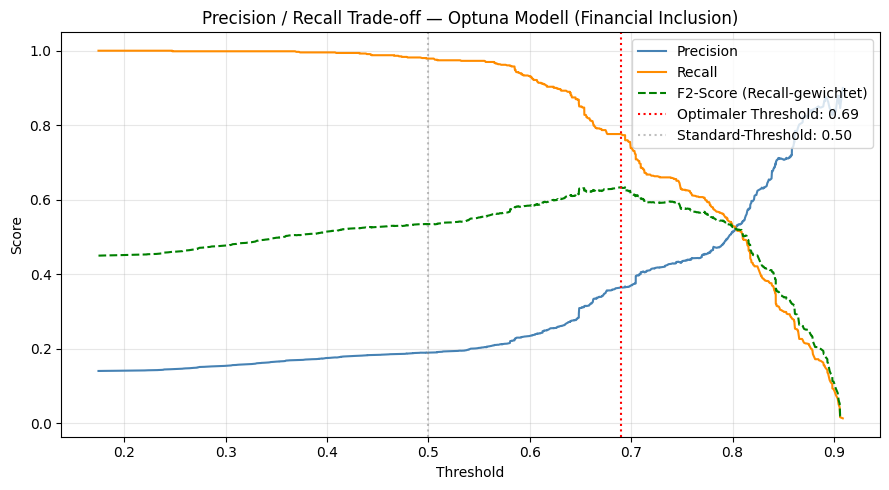

Optimaler Threshold (F2): 0.69
  Precision : 0.365
  Recall    : 0.776
  F2-Score  : 0.634


In [108]:
from sklearn.metrics import precision_recall_curve, f1_score

# Nach Step 6f: Optuna-Modell ist das beste — Threshold darauf neu berechnen
# (Step 6c hat noch das RandomizedSearch-Modell genutzt)
proba = best_model_optuna.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, proba)

# F2-Score: gewichtet Recall doppelt so stark wie Precision
# ideal für Financial Inclusion: wir tolerieren mehr False Positives um False Negatives zu vermeiden
f2_scores = (1 + 2**2) * (precisions * recalls) / ((2**2 * precisions) + recalls + 1e-9)
best_idx       = f2_scores.argmax()
best_threshold = thresholds[best_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='darkorange')
ax.plot(thresholds, f2_scores[:-1],  label='F2-Score (Recall-gewichtet)', color='green', linestyle='--')
ax.axvline(best_threshold, color='red', linestyle=':', label=f'Optimaler Threshold: {best_threshold:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Standard-Threshold: 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall Trade-off — Optuna Modell (Financial Inclusion)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimaler Threshold (F2): {best_threshold:.2f}')
print(f'  Precision : {precisions[best_idx]:.3f}')
print(f'  Recall    : {recalls[best_idx]:.3f}')
print(f'  F2-Score  : {f2_scores[best_idx]:.3f}')

=== Standard Threshold (0.50) ===
              precision    recall  f1-score   support

  Kein Konto       0.99      0.32      0.48      4043
       Konto       0.19      0.98      0.32       662

    accuracy                           0.41      4705
   macro avg       0.59      0.65      0.40      4705
weighted avg       0.88      0.41      0.46      4705

=== Optimierter Threshold (0.69) — Financial Inclusion ===
              precision    recall  f1-score   support

  Kein Konto       0.96      0.78      0.86      4043
       Konto       0.37      0.78      0.50       662

    accuracy                           0.78      4705
   macro avg       0.66      0.78      0.68      4705
weighted avg       0.87      0.78      0.81      4705



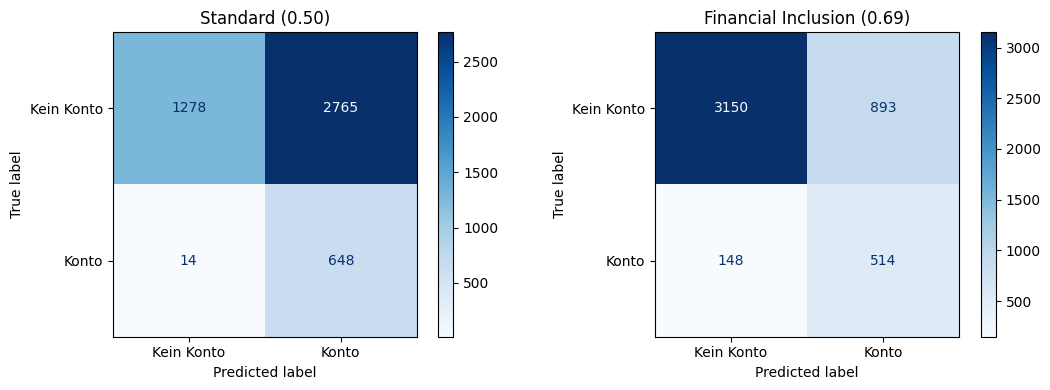

In [109]:
# Vergleich: Standard-Threshold (0.5) vs. optimierter Threshold
y_pred_standard = (proba >= 0.5).astype(int)
y_pred_tuned    = (proba >= best_threshold).astype(int)

print('=== Standard Threshold (0.50) ===')
print(classification_report(y_val, y_pred_standard, target_names=['Kein Konto', 'Konto']))

print(f'=== Optimierter Threshold ({best_threshold:.2f}) — Financial Inclusion ===')
print(classification_report(y_val, y_pred_tuned, target_names=['Kein Konto', 'Konto']))

# Confusion Matrix nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes,
    [y_pred_standard, y_pred_tuned],
    [f'Standard (0.50)', f'Financial Inclusion ({best_threshold:.2f})']):
    ConfusionMatrixDisplay.from_predictions(
        y_val, preds,
        display_labels=['Kein Konto', 'Konto'],
        cmap='Blues', ax=ax
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

---
### Step 6d — scale_pos_weight tunen

#### Was machen wir hier?

Unser Datensatz ist stark unbalanced — ~85% haben kein Konto, nur ~15% haben eins. Ohne Eingriff lernt das Modell: *"Sag immer Nein, dann liegst du meistens richtig."* Das wollen wir nicht — Financial Inclusion bedeutet: lieber zu viele Leute einschließen als jemanden fälschlicherweise ausschließen.

`scale_pos_weight` sagt dem Modell während des Trainings: **"Ein Fehler bei der Minderheitsklasse (Konto=1) ist X-mal schlimmer als ein Fehler bei der Mehrheitsklasse."**

| Wert | Bedeutung |
|---|---|
| ~5.7 | Natürliches Klassengewicht — kein Eingriff |
| ~8.5 | × 1.5 — bisheriger fixer Wert |
| 12–16 | Stark auf Recall optimiert — Modell wird aggressiver |

**Je höher der Wert, desto mehr Recall — aber desto mehr False Positives entstehen auch.**

Bisher haben wir `scale_pos_weight` fest auf `natürlich × 1.5` gesetzt. Jetzt suchen wir mit Cross-Validation den optimalen Wert — bei welchem Recall am höchsten ist ohne dass das Modell kippt und alles als "Konto" klassifiziert. Der Plot zeigt die Recall-Kurve über alle getesteten Werte.

Fitting 3 folds for each of 7 candidates, totalling 21 fits

Bestes scale_pos_weight : 16
CV-Recall               : 0.9566


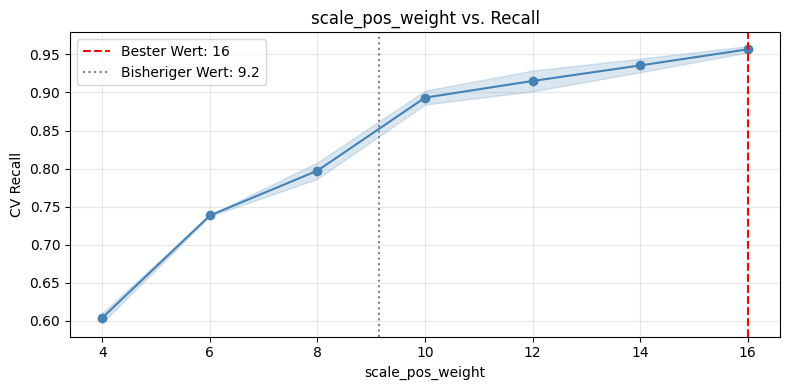

In [110]:
spw_grid = {
    'scale_pos_weight': [4, 6, 8, 10, 12, 14, 16],
}

spw_search = GridSearchCV(
    estimator=XGBClassifier(
        **{k: v for k, v in rand_search.best_params_.items()},
        eval_metric='auc',
        random_state=RANDOM_STATE,
    ),
    param_grid=spw_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

spw_search.fit(X_train, y_train)

best_spw = spw_search.best_params_['scale_pos_weight']
print(f'\nBestes scale_pos_weight : {best_spw}')
print(f'CV-Recall               : {spw_search.best_score_:.4f}')

# Vergleich über alle getesteten Werte
cv_results = pd.DataFrame(spw_search.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(spw_grid['scale_pos_weight'], cv_results['mean_test_score'], marker='o', color='steelblue')
plt.fill_between(
    spw_grid['scale_pos_weight'],
    cv_results['mean_test_score'] - cv_results['std_test_score'],
    cv_results['mean_test_score'] + cv_results['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.axvline(best_spw, color='red', linestyle='--', label=f'Bester Wert: {best_spw}')
plt.axvline(scale_pos_weight, color='grey', linestyle=':', label=f'Bisheriger Wert: {scale_pos_weight:.1f}')
plt.xlabel('scale_pos_weight')
plt.ylabel('CV Recall')
plt.title('scale_pos_weight vs. Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### Step 6e — Regularisierung: reg_alpha + reg_lambda

#### Was machen wir hier?

Regularisierung verhindert **Overfitting** — das Modell soll nicht die Trainingsdaten auswendig lernen, sondern echte Muster erkennen die auch auf neuen Daten funktionieren.

XGBoost hat zwei Regularisierungsparameter die auf unterschiedliche Weise eingreifen:

| Parameter | Typ | Wirkung |
|---|---|---|
| `reg_alpha` | L1 | Treibt unwichtige Feature-Gewichte auf genau **0** — wirkt wie automatische Feature Selection |
| `reg_lambda` | L2 | Bestraft große Gewichte — verteilt den Einfluss gleichmäßiger über alle Features |

**Warum ist das hier besonders relevant?**
Unser Modell hat 17 Features — einige davon (z.B. seltene Job-Kategorien wie `ohe_job_Government Dependent`) haben wenig Signal aber können das Modell trotzdem beeinflussen. `reg_alpha` kann diese effektiv ausschalten. `reg_lambda` verhindert dass das Modell zu stark auf einzelne dominante Features setzt — besonders wichtig bei unserem imbalanced Dataset wo das Modell sonst Shortcuts lernt.

Wir bauen auf den besten Parametern aus Step 6b + dem optimalen `scale_pos_weight` aus Step 6d auf. Die Heatmap zeigt welche Kombination aus L1 und L2 den höchsten Recall liefert.

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Beste Parameter:
  reg_alpha  : 2.0
  reg_lambda : 1.0
  CV-Recall  : 0.9581


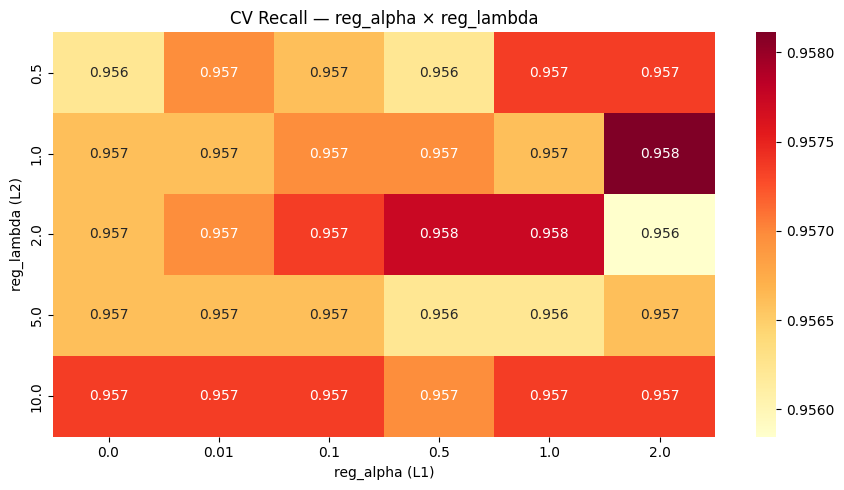

In [111]:
reg_grid = {
    'reg_alpha':  [0, 0.01, 0.1, 0.5, 1.0, 2.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0, 10.0],
}

reg_search = GridSearchCV(
    estimator=XGBClassifier(
        **{k: v for k, v in rand_search.best_params_.items()},
        scale_pos_weight=best_spw,
        eval_metric='auc',
        random_state=RANDOM_STATE,
    ),
    param_grid=reg_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

reg_search.fit(X_train, y_train)

best_alpha  = reg_search.best_params_['reg_alpha']
best_lambda = reg_search.best_params_['reg_lambda']

print(f'\nBeste Parameter:')
print(f'  reg_alpha  : {best_alpha}')
print(f'  reg_lambda : {best_lambda}')
print(f'  CV-Recall  : {reg_search.best_score_:.4f}')

# Heatmap: reg_alpha vs reg_lambda
results_df = pd.DataFrame(reg_search.cv_results_)
pivot = results_df.pivot_table(
    index='param_reg_lambda',
    columns='param_reg_alpha',
    values='mean_test_score'
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('CV Recall — reg_alpha × reg_lambda')
plt.xlabel('reg_alpha (L1)')
plt.ylabel('reg_lambda (L2)')
plt.tight_layout()
plt.show()

---
### Step 6f — Optuna: Bayesian Hyperparameter Optimization

#### Was machen wir hier?

GridSearch und RandomizedSearch haben einen Nachteil: sie lernen nichts aus ihren Versuchen. GridSearch testet stur alle Kombinationen, RandomizedSearch sampelt zufällig — beide "wissen" nicht ob ein Versuch gut oder schlecht war.

**Optuna macht das smarter:** Es ist eine *Bayesian Optimization* — nach jedem Versuch baut Optuna ein internes Modell darüber was gute Parameter-Kombinationen ausmacht und fokussiert die nächsten Versuche gezielt in vielversprechenden Bereichen. Es lernt also während des Suchens.

**Wie funktioniert es konkret?**
1. Wir definieren eine `objective`-Funktion die für eine Parameterkombination den CV-Recall zurückgibt
2. Optuna ruft diese Funktion 50× auf — aber nicht zufällig, sondern immer informierter
3. Am Ende gibt es die beste gefundene Kombination zurück

**Was wird getuned?**
Alle bisherigen Parameter in einem Durchlauf:
- `n_estimators`, `max_depth`, `learning_rate`
- `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`
- `scale_pos_weight` (aus Step 6d)
- `reg_alpha`, `reg_lambda` (aus Step 6e)

Am Ende vergleichen wir alle Modelle von Step 3 bis 6f direkt gegeneinander.

In [112]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 0.5),
        'scale_pos_weight':  trial.suggest_int('scale_pos_weight', 4, 16),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 10.0),
    }

    model = XGBClassifier(
        **params,
        eval_metric='auc',
        random_state=RANDOM_STATE,
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBeste Parameter:')
for k, v in study.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'\nBester Recall (Optuna): {study.best_value:.4f}')

Best trial: 45. Best value: 0.970188: 100%|██████████| 50/50 [00:11<00:00,  4.34it/s]


Beste Parameter:
  n_estimators          : 104
  max_depth             : 3
  learning_rate         : 0.022187070676123667
  subsample             : 0.5577561790500554
  colsample_bytree      : 0.9779949783748615
  min_child_weight      : 3
  gamma                 : 0.10488052635043901
  scale_pos_weight      : 16
  reg_alpha             : 1.7794842191190943
  reg_lambda            : 8.086776672108446

Bester Recall (Optuna): 0.9702


=== Modellvergleich — ROC-AUC auf Validation-Set ===
  Baseline (Step 3)        : 0.8738
  GridSearch (Step 6)      : 0.8453
  RandomizedSearch (Step 6b): 0.8644
  Optuna (Step 6f)         : 0.8514



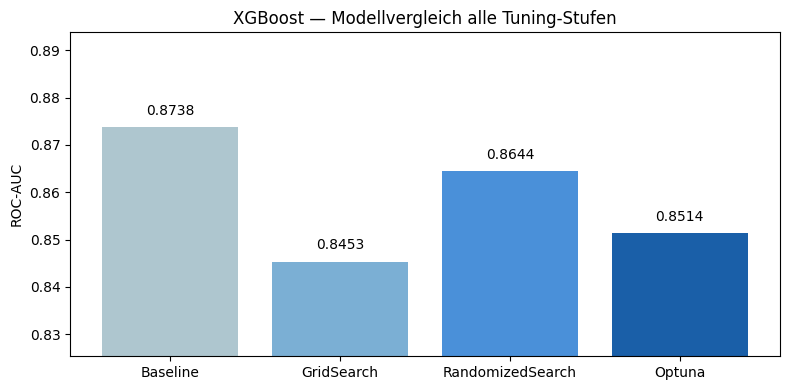

In [113]:
# Optuna-Modell auf Validation evaluieren
best_model_optuna = XGBClassifier(
    **study.best_params,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)
best_model_optuna.fit(X_train, y_train)

y_val_proba_optuna = best_model_optuna.predict_proba(X_val)[:, 1]
auc_optuna = roc_auc_score(y_val, y_val_proba_optuna)

# Gesamtvergleich aller Modelle
print('=== Modellvergleich — ROC-AUC auf Validation-Set ===')
print(f'  Baseline (Step 3)        : {auc:.4f}')
print(f'  GridSearch (Step 6)      : {auc_tuned:.4f}')
print(f'  RandomizedSearch (Step 6b): {auc_v2:.4f}')
print(f'  Optuna (Step 6f)         : {auc_optuna:.4f}')
print()

# Balkendiagramm
labels  = ['Baseline', 'GridSearch', 'RandomizedSearch', 'Optuna']
scores  = [auc, auc_tuned, auc_v2, auc_optuna]
colors  = ['#aec6cf', '#7bafd4', '#4a90d9', '#1a5fa8']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, scores, color=colors)
ax.set_ylim(min(scores) - 0.02, max(scores) + 0.02)
ax.set_ylabel('ROC-AUC')
ax.set_title('XGBoost — Modellvergleich alle Tuning-Stufen')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---
### Step 7 — Predictions auf Test-Daten

Wir generieren die finalen Predictions auf den echten Test-Daten und speichern sie als DataFrame — **noch keine CSV**, da wir später alle Modelle vergleichen und dann gemeinsam entscheiden welches wir einreichen.

Vorgehen:
1. Bestes Modell auf **allen** Trainingsdaten neu trainieren (kein 80/20-Split mehr — mehr Daten = besser)
2. Optimierten Threshold aus Step 6c anwenden
3. Predictions als DataFrame festhalten

In [114]:
# Finales Modell = Optuna-Modell (bestes aus allen Tuning-Stufen)
# Auf ALLEN Trainingsdaten neu trainieren — kein 80/20-Split mehr
final_model = XGBClassifier(
    **study.best_params,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)
final_model.fit(X, y)
print('Finales Modell (Optuna) auf allen Trainingsdaten trainiert.')

# Test-Daten laden und Predictions generieren
X_test = pd.read_csv('data/features_encoded_TEST.csv')
test_proba = final_model.predict_proba(X_test)[:, 1]

# Optimierten Threshold aus Step 6c anwenden
test_pred = (test_proba >= best_threshold).astype(int)

# IDs aufbauen: uniqueid + ' x ' + country
train_raw = pd.read_csv('data/Train.csv')[['uniqueid', 'country']]
test_raw  = pd.read_csv('data/Test.csv')[['uniqueid', 'country']]

train_raw['unique_id'] = train_raw['uniqueid'] + ' x ' + train_raw['country']
test_raw['unique_id']  = test_raw['uniqueid']  + ' x ' + test_raw['country']

# Predictions für Train- und Test-Rows
train_proba_final = final_model.predict_proba(X)[:, 1]

df_preds_xgboost = pd.concat([
    pd.DataFrame({'unique_id': train_raw['unique_id'].values, 'bank_account': train_proba_final}),
    pd.DataFrame({'unique_id': test_raw['unique_id'].values,  'bank_account': test_proba}),
], ignore_index=True)

print(f'\nPredictions bereit : {len(df_preds_xgboost):,} Zeilen')
print(f'Threshold          : {best_threshold:.2f}')
print(f'Anteil "Konto=1"   : {test_pred.mean()*100:.1f}% der Test-Personen')
df_preds_xgboost.head(3)

Finales Modell (Optuna) auf allen Trainingsdaten trainiert.

Predictions bereit : 33,610 Zeilen
Threshold          : 0.69
Anteil "Konto=1"   : 30.2% der Test-Personen


,unique_id,bank_account
0,uniqueid_1 x Kenya,0.782342
1,uniqueid_2 x Kenya,0.521578
2,uniqueid_3 x Kenya,0.917590


---
### Step 8 — Evaluation des finalen Modells

#### Warum zwei Evaluierungsmethoden?

Da das finale Modell auf **allen** Trainingsdaten trainiert wurde (kein Validation-Set mehr), können wir es nicht einfach auf denselben Daten testen — das wäre wie eine Prüfung bei der man die Fragen vorher kennt.

Deshalb nutzen wir zwei komplementäre Methoden:

**1. Cross-Validation (5-Fold):**
Die Daten werden in 5 gleiche Teile aufgeteilt. Das Modell wird 5× trainiert — jedes Mal auf 4 Teilen, getestet auf dem 5. Teil der beim Training nicht gesehen wurde. So bekommt jede Zeile einmal die Rolle des Testsets. Das Ergebnis ist ein **ehrlicher Durchschnittswert mit Standardabweichung** — die Standardabweichung zeigt wie stabil das Modell ist.

**2. Validation-Set mit optimiertem Threshold:**
Wir evaluieren auf dem ursprünglichen 20%-Validation-Split aus Step 2 mit dem Threshold aus Step 6c. Das gibt uns eine konkrete Confusion Matrix und den Classification Report mit Precision, Recall und F1.

**Zusammen** zeigen beide Methoden: ist das Modell generell gut (CV) und was bedeutet das konkret in Zahlen (Validation-Set)?

=== Cross-Validation (5-Fold) — Finales Modell ===
ROC-AUC : 0.8467  ± 0.0086
Recall  : 0.9743  ± 0.0046

=== Validation-Set Evaluation (Threshold: 0.69) ===
ROC-AUC: 0.8560

              precision    recall  f1-score   support

  Kein Konto       0.96      0.77      0.85      4043
       Konto       0.36      0.78      0.49       662

    accuracy                           0.77      4705
   macro avg       0.66      0.78      0.67      4705
weighted avg       0.87      0.77      0.80      4705



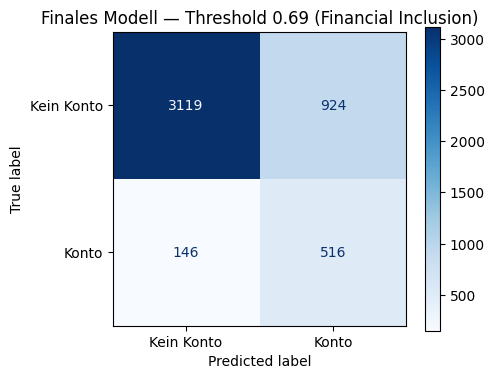

In [115]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# AUC und Recall via Cross-Validation
cv_auc    = cross_val_score(final_model, X, y, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_recall = cross_val_score(final_model, X, y, cv=cv, scoring='recall',   n_jobs=-1)

print('=== Cross-Validation (5-Fold) — Finales Modell ===')
print(f'ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}')
print(f'Recall  : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}')
print()

# Validation-Set Evaluation mit optimiertem Threshold
y_final_proba = final_model.predict_proba(X_val)[:, 1]
y_final_pred  = (y_final_proba >= best_threshold).astype(int)

auc_final = roc_auc_score(y_val, y_final_proba)

print(f'=== Validation-Set Evaluation (Threshold: {best_threshold:.2f}) ===')
print(f'ROC-AUC: {auc_final:.4f}')
print()
print(classification_report(y_val, y_final_pred, target_names=['Kein Konto', 'Konto']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_final_pred,
    display_labels=['Kein Konto', 'Konto'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Finales Modell — Threshold {best_threshold:.2f} (Financial Inclusion)')
plt.tight_layout()
plt.show()